# Depth Anything V2 Validation
**Dataset used: Raw 17-Min Videos and Collision Video**

This notebook validates Depth Anything V2 outputs for the pipeline of the thesis using:

1. `sunset_6fps_17mins.mp4` — SUN / Mild low-light raw video  
2. `collisions_6fps_resized.mp4` — COL / Supplemental STOP-event video  

The notebook runs **Depth Anything V2 inference only**. It does **not train DAV2**.  
Validation focuses on **relative depth consistency**, not exact metric depth accuracy, because no ground-truth depth labels, calibrated camera intrinsics, or GPS/IMU pose references are used.

Outputs are saved under:

`/content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE`

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 2. Install and Load Depth Anything V2

Keep the same `MODEL_SIZE` for every video so the validation is fair across bins.

In [2]:
%cd /content

!pip -q install huggingface_hub tqdm pandas matplotlib opencv-python openpyxl

!rm -rf Depth-Anything-V2
!git clone -q https://github.com/DepthAnything/Depth-Anything-V2.git

%cd /content/Depth-Anything-V2
!pip -q install -r requirements.txt || true

/content
/content/Depth-Anything-V2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 11.4 MB/s eta 0:00:00


## 3. Imports and Global Configuration

Important controls:

- `VALIDATION_MAX_WIDTH`: resizes frames to a consistent validation width before DAV2 inference. This keeps runtime and storage manageable. Set to `None` only if you intentionally want full-resolution validation.
- `VALIDATION_FRAME_STEP`: set to `1` for full validation of every frame. Increase for a quick test only.
- `MAX_FRAMES_PER_VIDEO`: keep as `None` for full videos.

In [3]:
import os
import sys
import cv2
import json
import math
import time
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import display, Image
from huggingface_hub import hf_hub_download

warnings.filterwarnings("ignore")

# Depth Anything V2 import.
sys.path.append("/content/Depth-Anything-V2")
from depth_anything_v2.dpt import DepthAnythingV2

# -----------------------------
# Project paths
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis2")
DATASET_DIR = PROJECT_ROOT / "Thesis2_6fpsRawVideos"

OUTPUT_ROOT = PROJECT_ROOT / "[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE"
TABLE_DIR = OUTPUT_ROOT / "tables_csv"
PLOT_DIR = OUTPUT_ROOT / "plots"
PER_VIDEO_PLOT_DIR = PLOT_DIR / "per_video"
SAMPLE_DIR = OUTPUT_ROOT / "sample_validation_pairs"
DEPTH_SAMPLE_DIR = OUTPUT_ROOT / "sample_depth_outputs"
LOG_DIR = OUTPUT_ROOT / "logs"

for folder in [OUTPUT_ROOT, TABLE_DIR, PLOT_DIR, PER_VIDEO_PLOT_DIR, SAMPLE_DIR, DEPTH_SAMPLE_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# DAV2 settings
# -----------------------------
MODEL_SIZE = "small"       # Options: "small", "base", "large"
DAV2_INPUT_SIZE = 518      # Standard DAV2 inference input size.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# Validation settings
# -----------------------------
VALIDATION_MAX_WIDTH = 960     # Set None for full input resolution. 960 is practical for Colab validation.
VALIDATION_FRAME_STEP = 1      # 1 = every frame. Increase only for quick testing.
MAX_FRAMES_PER_VIDEO = None    # None = full video. Set e.g. 300 for smoke test.
REPROJECTION_ALPHA = 0.85      # Proposal equation weighting: SSIM-heavy photometric error.
SAVE_EVERY_ROWS = 250          # Save progress CSV every N validated rows.
SKIP_IF_OUTPUT_EXISTS = True   # Loads existing CSV outputs if already produced.

# Central road ROI used for depth summary. Adjust only if your final CaVi ROI differs.
ROI_X1_RATIO = 0.35
ROI_X2_RATIO = 0.65
ROI_Y1_RATIO = 0.45
ROI_Y2_RATIO = 0.95

print("Project root:", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Output folder:", OUTPUT_ROOT)
print("Device:", DEVICE)

Project root: /content/drive/MyDrive/Thesis2
Dataset folder: /content/drive/MyDrive/Thesis2/Thesis2_6fpsRawVideos
Output folder: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE
Device: cuda


## 4. Define Videos to Validate

The three 17-minute raw videos represent the main low-light bins. The collision video is supplemental STOP-event data. The enhanced evening video is included to preserve the original DAV2 validation case.

In [ ]:
VIDEO_SPECS = [
    {
        "source_id": "SUN_RAW_17MIN",
        "bin_code": "SUN",
        "lighting_bin": "Mild Low-Light",
        "time_label": "Sunset",
        "source_type": "Raw Video",
        "filename": "sunset_6fps_17mins.mp4"
    },
    {
        "source_id": "EVE_RAW_17MIN",
        "bin_code": "EVE",
        "lighting_bin": "Moderate Low-Light",
        "time_label": "Evening",
        "source_type": "Raw Video",
        "filename": "evening_6fps_17mins.mp4"
    },
    {
        "source_id": "MID_RAW_17MIN",
        "bin_code": "MID",
        "lighting_bin": "Severe Low-Light",
        "time_label": "Midnight",
        "source_type": "Raw Video",
        "filename": "midnight_6fps_17mins.mp4"
    },
    {
        "source_id": "COL_RAW_RESIZED",
        "bin_code": "COL",
        "lighting_bin": "Supplemental STOP-Event",
        "time_label": "Collision",
        "source_type": "Raw Collision Video",
        "filename": "collisions_6fps_resized.mp4"
    },
    {
        "source_id": "EVE_ZERO3DCE_ENHANCED",
        "bin_code": "EVE",
        "lighting_bin": "Moderate Low-Light",
        "time_label": "Evening",
        "source_type": "Zero-3DCE Enhanced Video",
        "filename": "evening_zero3dce_enhanced.mp4"
    }
]

for spec in VIDEO_SPECS:
    spec["video_path"] = DATASET_DIR / spec["filename"]

missing = [str(spec["video_path"]) for spec in VIDEO_SPECS if not spec["video_path"].exists()]
if missing:
    raise FileNotFoundError("Missing expected video file(s):\n" + "\n".join(missing))

video_inventory_rows = []

for spec in VIDEO_SPECS:
    cap = cv2.VideoCapture(str(spec["video_path"]))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_sec = frame_count / fps if fps > 0 else np.nan
    cap.release()

    video_inventory_rows.append({
        "source_id": spec["source_id"],
        "bin_code": spec["bin_code"],
        "lighting_bin": spec["lighting_bin"],
        "time_label": spec["time_label"],
        "source_type": spec["source_type"],
        "filename": spec["filename"],
        "video_path": str(spec["video_path"]),
        "fps": fps,
        "frame_count": frame_count,
        "duration_minutes": duration_sec / 60 if not np.isnan(duration_sec) else np.nan,
        "width": width,
        "height": height
    })

video_inventory_df = pd.DataFrame(video_inventory_rows)
video_inventory_path = TABLE_DIR / "video_inventory.csv"
video_inventory_df.to_csv(video_inventory_path, index=False)

print("Saved:", video_inventory_path)
display(video_inventory_df)

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/tables_csv/video_inventory.csv


,source_id,bin_code,lighting_bin,time_label,source_type,filename,video_path,fps,frame_count,duration_minutes,width,height
0,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,29.99902,30612,17.007222,1920,1080
1,EVE_RAW_17MIN,EVE,Moderate Low-Light,Evening,Raw Video,evening_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,29.99902,30612,17.007222,1920,1080
2,MID_RAW_17MIN,MID,Severe Low-Light,Midnight,Raw Video,midnight_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,29.99902,30612,17.007222,1920,1080
3,COL_RAW_RESIZED,COL,Supplemental STOP-Event,Collision,Raw Collision Video,collisions_6fps_resized.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,10.00000,1081,1.801667,1920,1080
4,EVE_ZERO3DCE_ENHANCED,EVE,Moderate Low-Light,Evening,Zero-3DCE Enhanced Video,evening_zero3dce_enhanced.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,6.00000,12242,34.005556,518,518


## 5. Download and Load Pretrained Depth Anything V2

This uses pretrained DAV2 only. No DAV2 training happens in this notebook.

In [4]:
MODEL_CONFIGS = {
    "small": {
        "encoder": "vits",
        "features": 64,
        "out_channels": [48, 96, 192, 384],
        "repo_id": "depth-anything/Depth-Anything-V2-Small",
        "filename": "depth_anything_v2_vits.pth"
    },
    "base": {
        "encoder": "vitb",
        "features": 128,
        "out_channels": [96, 192, 384, 768],
        "repo_id": "depth-anything/Depth-Anything-V2-Base",
        "filename": "depth_anything_v2_vitb.pth"
    },
    "large": {
        "encoder": "vitl",
        "features": 256,
        "out_channels": [256, 512, 1024, 1024],
        "repo_id": "depth-anything/Depth-Anything-V2-Large",
        "filename": "depth_anything_v2_vitl.pth"
    }
}

cfg = MODEL_CONFIGS[MODEL_SIZE]
CHECKPOINT_DIR = Path("/content/Depth-Anything-V2/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = hf_hub_download(
    repo_id=cfg["repo_id"],
    filename=cfg["filename"],
    local_dir=str(CHECKPOINT_DIR)
)

depth_model = DepthAnythingV2(
    encoder=cfg["encoder"],
    features=cfg["features"],
    out_channels=cfg["out_channels"]
)

state_dict = torch.load(checkpoint_path, map_location="cpu")
depth_model.load_state_dict(state_dict)
depth_model = depth_model.to(DEVICE).eval()

print("Loaded Depth Anything V2:", MODEL_SIZE)
print("Checkpoint:", checkpoint_path)
print("Device:", DEVICE)

depth_anything_v2_vits.pth:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loaded Depth Anything V2: small
Checkpoint: /content/Depth-Anything-V2/checkpoints/depth_anything_v2_vits.pth
Device: cuda


## 6. Helper Functions

This section defines:

- depth visualization
- center ROI depth statistics
- adjacent-frame alignment using dense optical flow
- minimum reprojection loss
- normalized depth temporal MAE/RMSE
- sample validation-pair plotting

The warping step uses optical-flow alignment because this dataset does not include calibrated camera intrinsics and pose. This follows the practical consistency-check style used in the current DAV2 validation notebook. It should be reported as **adjacent-frame relative consistency**, not metric depth accuracy.

In [5]:
DAV2_CMAP = plt.get_cmap("magma")

def resize_frame_max_width(frame_bgr, max_width=None):
    """Resize a frame to a maximum width while preserving aspect ratio."""
    if max_width is None:
        return frame_bgr

    h, w = frame_bgr.shape[:2]
    if w <= max_width:
        return frame_bgr

    scale = max_width / float(w)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    return cv2.resize(frame_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)


def normalize01(array):
    """Normalize an array to [0, 1] safely."""
    array = array.astype(np.float32)
    min_value = float(np.min(array))
    max_value = float(np.max(array))

    if max_value - min_value < 1e-8:
        return np.zeros_like(array, dtype=np.float32)

    return (array - min_value) / (max_value - min_value)


def apply_dav2_colormap(depth_map):
    """Convert a depth map into a Magma RGB visualization."""
    depth01 = normalize01(depth_map)
    colored = DAV2_CMAP(depth01)[:, :, :3]
    return (colored * 255).astype(np.uint8)


def compute_center_roi_stats(depth_map):
    """Compute relative depth statistics for the central road ROI."""
    h, w = depth_map.shape[:2]

    x1 = int(w * ROI_X1_RATIO)
    x2 = int(w * ROI_X2_RATIO)
    y1 = int(h * ROI_Y1_RATIO)
    y2 = int(h * ROI_Y2_RATIO)

    roi_depth = depth_map[y1:y2, x1:x2]

    return {
        "center_roi_mean": float(np.mean(roi_depth)),
        "center_roi_median": float(np.median(roi_depth)),
        "center_roi_std": float(np.std(roi_depth)),
        "center_roi_min": float(np.min(roi_depth)),
        "center_roi_max": float(np.max(roi_depth)),
        "roi_x1": x1,
        "roi_y1": y1,
        "roi_x2": x2,
        "roi_y2": y2
    }


def compute_ssim_map(gray_a, gray_b):
    """Compute local SSIM map."""
    gray_a = gray_a.astype(np.float32)
    gray_b = gray_b.astype(np.float32)

    c1 = 0.01 ** 2
    c2 = 0.03 ** 2

    mu_a = cv2.GaussianBlur(gray_a, (11, 11), 1.5)
    mu_b = cv2.GaussianBlur(gray_b, (11, 11), 1.5)

    mu_a_sq = mu_a * mu_a
    mu_b_sq = mu_b * mu_b
    mu_ab = mu_a * mu_b

    sigma_a_sq = cv2.GaussianBlur(gray_a * gray_a, (11, 11), 1.5) - mu_a_sq
    sigma_b_sq = cv2.GaussianBlur(gray_b * gray_b, (11, 11), 1.5) - mu_b_sq
    sigma_ab = cv2.GaussianBlur(gray_a * gray_b, (11, 11), 1.5) - mu_ab

    numerator = (2 * mu_ab + c1) * (2 * sigma_ab + c2)
    denominator = (mu_a_sq + mu_b_sq + c1) * (sigma_a_sq + sigma_b_sq + c2)

    ssim_map = numerator / np.maximum(denominator, 1e-8)
    return np.clip(ssim_map, -1.0, 1.0)


def photometric_reprojection_error(target_rgb, warped_source_rgb, valid_mask=None, alpha=0.85):
    """
    Compute photometric reprojection error:
    alpha * ((1 - SSIM) / 2) + (1 - alpha) * L1
    """
    target_rgb01 = target_rgb.astype(np.float32) / 255.0
    warped_rgb01 = warped_source_rgb.astype(np.float32) / 255.0

    target_gray = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    warped_gray = cv2.cvtColor(warped_source_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    ssim_map = compute_ssim_map(target_gray, warped_gray)
    ssim_loss_map = (1.0 - ssim_map) / 2.0
    l1_map = np.mean(np.abs(target_rgb01 - warped_rgb01), axis=2)

    error_map = (alpha * ssim_loss_map) + ((1.0 - alpha) * l1_map)

    if valid_mask is not None:
        valid_mask = valid_mask.astype(bool)
        if np.sum(valid_mask) == 0:
            return np.nan, error_map
        return float(np.mean(error_map[valid_mask])), error_map

    return float(np.mean(error_map)), error_map


def warp_source_to_target_with_optical_flow(source_rgb, target_rgb):
    """Warp source frame into target frame using target-to-source dense optical flow."""
    target_gray_u8 = cv2.cvtColor(target_rgb, cv2.COLOR_RGB2GRAY)
    source_gray_u8 = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2GRAY)

    flow_target_to_source = cv2.calcOpticalFlowFarneback(
        target_gray_u8,
        source_gray_u8,
        None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )

    h, w = target_gray_u8.shape
    grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))

    map_x = (grid_x + flow_target_to_source[..., 0]).astype(np.float32)
    map_y = (grid_y + flow_target_to_source[..., 1]).astype(np.float32)

    valid_mask = (
        (map_x >= 0) & (map_x <= w - 1) &
        (map_y >= 0) & (map_y <= h - 1)
    )

    warped_source_rgb = cv2.remap(
        source_rgb,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return warped_source_rgb, valid_mask, map_x, map_y


def warp_map_with_remap(source_map, map_x, map_y):
    """Warp a single-channel map using remap coordinates."""
    return cv2.remap(
        source_map.astype(np.float32),
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )


def run_dav2_inference(frame_bgr):
    """Run Depth Anything V2 on a BGR frame and return relative depth map."""
    with torch.no_grad():
        try:
            depth = depth_model.infer_image(frame_bgr, input_size=DAV2_INPUT_SIZE)
        except TypeError:
            depth = depth_model.infer_image(frame_bgr)
    return depth.astype(np.float32)


def validate_target_against_sources(target_item, source_items):
    """Compute minimum reprojection loss for a target frame using available adjacent source frames."""
    candidate_results = []

    target_rgb = target_item["frame_rgb"]
    target_depth01 = target_item["depth01"]

    for source_item, source_direction in source_items:
        source_rgb = source_item["frame_rgb"]
        source_depth01 = source_item["depth01"]

        warped_source_rgb, valid_mask, map_x, map_y = warp_source_to_target_with_optical_flow(
            source_rgb=source_rgb,
            target_rgb=target_rgb
        )

        photometric_loss, error_map = photometric_reprojection_error(
            target_rgb=target_rgb,
            warped_source_rgb=warped_source_rgb,
            valid_mask=valid_mask,
            alpha=REPROJECTION_ALPHA
        )

        warped_source_depth01 = warp_map_with_remap(source_depth01, map_x, map_y)
        depth_abs_diff = np.abs(target_depth01 - warped_source_depth01)

        if np.sum(valid_mask) > 0:
            depth_temporal_mae = float(np.mean(depth_abs_diff[valid_mask]))
            depth_temporal_rmse = float(np.sqrt(np.mean((depth_abs_diff[valid_mask]) ** 2)))
            valid_pixel_ratio = float(np.mean(valid_mask))
        else:
            depth_temporal_mae = np.nan
            depth_temporal_rmse = np.nan
            valid_pixel_ratio = 0.0

        candidate_results.append({
            "source_direction": source_direction,
            "source_frame_index": source_item["frame_index"],
            "photometric_reprojection_loss": photometric_loss,
            "depth_temporal_mae": depth_temporal_mae,
            "depth_temporal_rmse": depth_temporal_rmse,
            "valid_pixel_ratio": valid_pixel_ratio,
            "target_rgb": target_rgb,
            "source_rgb": source_rgb,
            "warped_source_rgb": warped_source_rgb,
            "error_map": error_map,
            "target_depth01": target_depth01,
            "warped_source_depth01": warped_source_depth01,
            "depth_abs_diff": depth_abs_diff
        })

    valid_candidates = [
        item for item in candidate_results
        if not np.isnan(item["photometric_reprojection_loss"])
    ]

    if len(valid_candidates) == 0:
        return None

    return min(valid_candidates, key=lambda item: item["photometric_reprojection_loss"])


def save_validation_pair_figure(sample, source_id, label, output_dir):
    """Save a 2x3 validation-pair visualization."""
    output_dir = Path(output_dir) / source_id
    output_dir.mkdir(parents=True, exist_ok=True)

    target_idx = sample["target_frame_index"]
    figure_path = output_dir / f"{source_id}_{label}_target_{target_idx:06d}_validation_pair.png"

    plt.figure(figsize=(16, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(sample["target_rgb"])
    plt.title(f"Target Frame {target_idx}")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(sample["warped_source_rgb"])
    plt.title(f"Warped {sample['source_direction'].title()} Source {sample['source_frame_index']}")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(sample["error_map"], cmap="magma")
    plt.title(f"Photometric Error\\nLoss={sample['photometric_reprojection_loss']:.4f}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(sample["target_depth01"], cmap="magma")
    plt.title("Target DAV2 Depth\\nNormalized")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(sample["warped_source_depth01"], cmap="magma")
    plt.title("Warped Source DAV2 Depth")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(sample["depth_abs_diff"], cmap="magma")
    plt.title(f"Depth Difference\\nMAE={sample['depth_temporal_mae']:.4f}")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(figure_path, dpi=150)
    plt.close()

    return figure_path


def save_depth_sample_figure(item, source_id, output_dir):
    """Save frame and DAV2 depth visualization."""
    output_dir = Path(output_dir) / source_id
    output_dir.mkdir(parents=True, exist_ok=True)

    depth_vis_rgb = apply_dav2_colormap(item["depth"])
    figure_path = output_dir / f"{source_id}_frame_{item['frame_index']:06d}_dav2_depth_sample.png"

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(item["frame_rgb"])
    plt.title(f"{source_id}\\nFrame {item['frame_index']}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(depth_vis_rgb)
    plt.title("DAV2 Relative Depth")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(figure_path, dpi=150)
    plt.close()

    return figure_path

## 7. Process One Video: DAV2 Inference + Validation

This function streams through each video, computes DAV2 depth, validates adjacent-frame consistency, and saves CSV outputs without storing all depth maps as `.npy` files. This avoids extremely large Drive storage usage while still producing the validation tables and plots needed for Chapter 4.

In [6]:
def process_one_video(spec):
    """Run DAV2 inference and adjacent-frame validation for one video."""
    source_id = spec["source_id"]

    metadata_csv = TABLE_DIR / f"dav2_frame_depth_metadata_{source_id}.csv"
    validation_csv = TABLE_DIR / f"dav2_adjacent_frame_validation_{source_id}.csv"
    log_json = LOG_DIR / f"run_log_{source_id}.json"

    if SKIP_IF_OUTPUT_EXISTS and metadata_csv.exists() and validation_csv.exists():
        print(f"[SKIP] Existing outputs found for {source_id}. Loading CSVs.")
        metadata_df = pd.read_csv(metadata_csv)
        validation_df = pd.read_csv(validation_csv)
        return metadata_df, validation_df

    cap = cv2.VideoCapture(str(spec["video_path"]))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {spec['video_path']}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if MAX_FRAMES_PER_VIDEO is not None:
        expected_processed = min(MAX_FRAMES_PER_VIDEO, math.ceil(total_frames / VALIDATION_FRAME_STEP))
    else:
        expected_processed = math.ceil(total_frames / VALIDATION_FRAME_STEP) if total_frames > 0 else None

    sample_targets = set()
    if total_frames > 0:
        sample_targets = {
            int(total_frames * 0.10),
            int(total_frames * 0.50),
            int(total_frames * 0.90)
        }

    metadata_rows = []
    validation_rows = []
    buffer = []
    first_validated = False
    highest_loss_sample = None
    highest_loss_value = -1.0
    saved_fixed_samples = set()

    frame_idx = 0
    processed_count = 0
    start_time = time.time()

    progress = tqdm(total=expected_processed, desc=f"{source_id} DAV2 + validation", unit="frame")

    def add_validation_row(target_item, best_candidate):
        nonlocal highest_loss_sample, highest_loss_value

        if best_candidate is None:
            return

        row = {
            "source_id": source_id,
            "bin_code": spec["bin_code"],
            "lighting_bin": spec["lighting_bin"],
            "time_label": spec["time_label"],
            "source_type": spec["source_type"],
            "filename": spec["filename"],
            "target_frame_index": target_item["frame_index"],
            "best_source_frame_index": best_candidate["source_frame_index"],
            "best_source_direction": best_candidate["source_direction"],
            "min_reprojection_loss": best_candidate["photometric_reprojection_loss"],
            "depth_temporal_mae": best_candidate["depth_temporal_mae"],
            "depth_temporal_rmse": best_candidate["depth_temporal_rmse"],
            "valid_pixel_ratio": best_candidate["valid_pixel_ratio"],
            "alpha": REPROJECTION_ALPHA,
            "validation_max_width": VALIDATION_MAX_WIDTH,
            "dav2_input_size": DAV2_INPUT_SIZE,
            "model_size": MODEL_SIZE
        }
        validation_rows.append(row)

        # Save fixed sample visuals at 10%, 50%, and 90% positions.
        if target_item["frame_index"] in sample_targets and target_item["frame_index"] not in saved_fixed_samples:
            sample = {**best_candidate, "target_frame_index": target_item["frame_index"]}
            figure_path = save_validation_pair_figure(
                sample=sample,
                source_id=source_id,
                label=f"fixed_{len(saved_fixed_samples)+1:02d}",
                output_dir=SAMPLE_DIR
            )
            saved_fixed_samples.add(target_item["frame_index"])
            print("Saved sample validation pair:", figure_path)

        # Keep highest-loss sample for this video.
        loss_value = best_candidate["photometric_reprojection_loss"]
        if not np.isnan(loss_value) and loss_value > highest_loss_value:
            highest_loss_value = loss_value
            highest_loss_sample = {**best_candidate, "target_frame_index": target_item["frame_index"]}

    while True:
        ret, frame_bgr = cap.read()

        if not ret:
            break

        if frame_idx % VALIDATION_FRAME_STEP != 0:
            frame_idx += 1
            continue

        if MAX_FRAMES_PER_VIDEO is not None and processed_count >= MAX_FRAMES_PER_VIDEO:
            break

        frame_bgr = resize_frame_max_width(frame_bgr, VALIDATION_MAX_WIDTH)
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        depth = run_dav2_inference(frame_bgr)
        depth01 = normalize01(depth)

        roi_stats = compute_center_roi_stats(depth)

        item = {
            "frame_index": frame_idx,
            "processed_index": processed_count,
            "frame_rgb": frame_rgb,
            "depth": depth,
            "depth01": depth01
        }

        # Save a small number of frame-depth samples, not all frames.
        if processed_count in [0, int((expected_processed or 1) * 0.50)]:
            save_depth_sample_figure(item, source_id, DEPTH_SAMPLE_DIR)

        metadata_rows.append({
            "source_id": source_id,
            "bin_code": spec["bin_code"],
            "lighting_bin": spec["lighting_bin"],
            "time_label": spec["time_label"],
            "source_type": spec["source_type"],
            "filename": spec["filename"],
            "video_path": str(spec["video_path"]),
            "frame_index": frame_idx,
            "processed_index": processed_count,
            "working_width": frame_rgb.shape[1],
            "working_height": frame_rgb.shape[0],
            "original_width": width,
            "original_height": height,
            "fps": fps,
            "depth_mean": float(np.mean(depth)),
            "depth_median": float(np.median(depth)),
            "depth_std": float(np.std(depth)),
            "depth_min": float(np.min(depth)),
            "depth_max": float(np.max(depth)),
            **roi_stats
        })

        buffer.append(item)

        # Validate the first frame once the next frame is available.
        if len(buffer) == 2 and not first_validated:
            target_item = buffer[0]
            source_items = [(buffer[1], "next")]
            best = validate_target_against_sources(target_item, source_items)
            add_validation_row(target_item, best)
            first_validated = True

        # Validate the middle frame when previous and next frames are available.
        if len(buffer) >= 3:
            target_item = buffer[1]
            source_items = [(buffer[0], "previous"), (buffer[2], "next")]
            best = validate_target_against_sources(target_item, source_items)
            add_validation_row(target_item, best)
            buffer.pop(0)

        processed_count += 1
        frame_idx += 1

        if len(validation_rows) > 0 and len(validation_rows) % SAVE_EVERY_ROWS == 0:
            pd.DataFrame(metadata_rows).to_csv(metadata_csv, index=False)
            pd.DataFrame(validation_rows).to_csv(validation_csv, index=False)

        elapsed = time.time() - start_time
        fps_runtime = processed_count / max(elapsed, 1e-8)
        progress.update(1)
        progress.set_postfix({
            "processed": processed_count,
            "runtime_fps": f"{fps_runtime:.2f}",
            "elapsed_min": f"{elapsed/60:.1f}"
        })

    cap.release()
    progress.close()

    # Validate final frame using previous frame only.
    if len(buffer) >= 2:
        target_item = buffer[-1]
        source_items = [(buffer[-2], "previous")]
        best = validate_target_against_sources(target_item, source_items)
        add_validation_row(target_item, best)

    # Save the highest-loss sample for edge-case discussion.
    if highest_loss_sample is not None:
        figure_path = save_validation_pair_figure(
            sample=highest_loss_sample,
            source_id=source_id,
            label="highest_loss",
            output_dir=SAMPLE_DIR
        )
        print("Saved highest-loss validation pair:", figure_path)

    metadata_df = pd.DataFrame(metadata_rows)
    validation_df = pd.DataFrame(validation_rows)

    metadata_df.to_csv(metadata_csv, index=False)
    validation_df.to_csv(validation_csv, index=False)

    run_log = {
        "source_id": source_id,
        "filename": spec["filename"],
        "video_path": str(spec["video_path"]),
        "total_video_frames": total_frames,
        "processed_frames": int(len(metadata_df)),
        "validated_targets": int(len(validation_df)),
        "fps": fps,
        "original_width": width,
        "original_height": height,
        "validation_max_width": VALIDATION_MAX_WIDTH,
        "validation_frame_step": VALIDATION_FRAME_STEP,
        "max_frames_per_video": MAX_FRAMES_PER_VIDEO,
        "model_size": MODEL_SIZE,
        "dav2_input_size": DAV2_INPUT_SIZE,
        "elapsed_minutes": (time.time() - start_time) / 60
    }

    with open(log_json, "w", encoding="utf-8") as file:
        json.dump(run_log, file, indent=2)

    print(f"[DONE] {source_id}")
    print("Metadata CSV:", metadata_csv)
    print("Validation CSV:", validation_csv)
    print("Processed frames:", len(metadata_df))
    print("Validated targets:", len(validation_df))

    return metadata_df, validation_df

In [7]:
# ============================================================
# SUNSET + COLLISION ONLY RUNNER
# This loads finished SUNSET CSVs, then processes ONLY collision video.
# It saves to a separate folder so it will not ruin the full running notebook.
# ============================================================

from pathlib import Path
import cv2
import shutil
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis2")
DATASET_DIR = PROJECT_ROOT / "Thesis2_6fpsRawVideos"

# Original full-run folder where SUNSET was already completed
ORIGINAL_OUTPUT_ROOT = PROJECT_ROOT / "[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE"
ORIGINAL_TABLE_DIR = ORIGINAL_OUTPUT_ROOT / "tables_csv"
ORIGINAL_SAMPLE_DIR = ORIGINAL_OUTPUT_ROOT / "sample_validation_pairs"

# New separate output folder for the duplicate notebook
OUTPUT_ROOT = PROJECT_ROOT / "[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS"
TABLE_DIR = OUTPUT_ROOT / "tables_csv"
PLOT_DIR = OUTPUT_ROOT / "plots"
PER_VIDEO_PLOT_DIR = PLOT_DIR / "per_video"
SAMPLE_DIR = OUTPUT_ROOT / "sample_validation_pairs"
DEPTH_SAMPLE_DIR = OUTPUT_ROOT / "sample_depth_outputs"
LOG_DIR = OUTPUT_ROOT / "logs"

for folder in [OUTPUT_ROOT, TABLE_DIR, PLOT_DIR, PER_VIDEO_PLOT_DIR, SAMPLE_DIR, DEPTH_SAMPLE_DIR, LOG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Saving duplicate-notebook outputs to:", OUTPUT_ROOT)

# ------------------------------------------------------------
# 1. Load already completed SUNSET results from original run
# ------------------------------------------------------------
SUN_ID = "SUN_RAW_17MIN"

sun_metadata_path = ORIGINAL_TABLE_DIR / f"dav2_frame_depth_metadata_{SUN_ID}.csv"
sun_validation_path = ORIGINAL_TABLE_DIR / f"dav2_adjacent_frame_validation_{SUN_ID}.csv"
sun_inventory_path = ORIGINAL_TABLE_DIR / "video_inventory.csv"

if not sun_metadata_path.exists():
    raise FileNotFoundError(f"Missing SUN metadata CSV: {sun_metadata_path}")

if not sun_validation_path.exists():
    raise FileNotFoundError(f"Missing SUN validation CSV: {sun_validation_path}")

sun_metadata_df = pd.read_csv(sun_metadata_path)
sun_validation_df = pd.read_csv(sun_validation_path)

if sun_inventory_path.exists():
    sun_inventory_df = pd.read_csv(sun_inventory_path)
    sun_inventory_df = sun_inventory_df[sun_inventory_df["source_id"] == SUN_ID].copy()
else:
    sun_inventory_df = pd.DataFrame()

# Copy SUN sample validation pairs
src_sun_sample = ORIGINAL_SAMPLE_DIR / SUN_ID
dst_sun_sample = SAMPLE_DIR / SUN_ID

if src_sun_sample.exists():
    shutil.copytree(src_sun_sample, dst_sun_sample, dirs_exist_ok=True)
    print("Copied SUN sample pairs to:", dst_sun_sample)

print("Loaded SUN metadata:", sun_metadata_df.shape)
print("Loaded SUN validation:", sun_validation_df.shape)

# ------------------------------------------------------------
# 2. Define and process ONLY the collision video
# ------------------------------------------------------------
COL_SPEC = {
    "source_id": "COL_RAW_RESIZED",
    "bin_code": "COL",
    "lighting_bin": "Supplemental STOP-Event",
    "time_label": "Collision",
    "source_type": "Raw Collision Video",
    "filename": "collisions_6fps_resized.mp4",
}

COL_SPEC["video_path"] = DATASET_DIR / COL_SPEC["filename"]

if not COL_SPEC["video_path"].exists():
    raise FileNotFoundError(f"Missing collision video: {COL_SPEC['video_path']}")

# Save collision video inventory row
cap = cv2.VideoCapture(str(COL_SPEC["video_path"]))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = float(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration_sec = frame_count / fps if fps > 0 else np.nan
cap.release()

col_inventory_df = pd.DataFrame([{
    "source_id": COL_SPEC["source_id"],
    "bin_code": COL_SPEC["bin_code"],
    "lighting_bin": COL_SPEC["lighting_bin"],
    "time_label": COL_SPEC["time_label"],
    "source_type": COL_SPEC["source_type"],
    "filename": COL_SPEC["filename"],
    "video_path": str(COL_SPEC["video_path"]),
    "fps": fps,
    "frame_count": frame_count,
    "duration_minutes": duration_sec / 60 if not np.isnan(duration_sec) else np.nan,
    "width": width,
    "height": height
}])

print("Collision video info:")
display(col_inventory_df)

print("\n" + "=" * 80)
print("Processing ONLY:", COL_SPEC["source_id"], "|", COL_SPEC["filename"])
print("=" * 80)

col_metadata_df, col_validation_df = process_one_video(COL_SPEC)

print("Collision metadata:", col_metadata_df.shape)
print("Collision validation:", col_validation_df.shape)

# ------------------------------------------------------------
# 3. Combine SUNSET + COLLISION only
# ------------------------------------------------------------
combined_metadata_df = pd.concat([sun_metadata_df, col_metadata_df], ignore_index=True)
combined_validation_df = pd.concat([sun_validation_df, col_validation_df], ignore_index=True)

video_inventory_df = pd.concat([sun_inventory_df, col_inventory_df], ignore_index=True)

combined_metadata_path = TABLE_DIR / "dav2_all_videos_frame_depth_metadata.csv"
combined_validation_path = TABLE_DIR / "dav2_all_videos_adjacent_frame_validation.csv"
video_inventory_path = TABLE_DIR / "video_inventory.csv"

combined_metadata_df.to_csv(combined_metadata_path, index=False)
combined_validation_df.to_csv(combined_validation_path, index=False)
video_inventory_df.to_csv(video_inventory_path, index=False)

print("Saved combined SUN + COL metadata:", combined_metadata_path)
print("Saved combined SUN + COL validation:", combined_validation_path)
print("Saved video inventory:", video_inventory_path)

display(video_inventory_df)
display(combined_metadata_df.head())
display(combined_validation_df.head())

Saving duplicate-notebook outputs to: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS
Copied SUN sample pairs to: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_validation_pairs/SUN_RAW_17MIN
Loaded SUN metadata: (30612, 28)
Loaded SUN validation: (30612, 17)
Collision video info:


,source_id,bin_code,lighting_bin,time_label,source_type,filename,video_path,fps,frame_count,duration_minutes,width,height
0,COL_RAW_RESIZED,COL,Supplemental STOP-Event,Collision,Raw Collision Video,collisions_6fps_resized.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,10.0,1081,1.801667,1920,1080



Processing ONLY: COL_RAW_RESIZED | collisions_6fps_resized.mp4


COL_RAW_RESIZED DAV2 + validation:   0%|          | 0/1081 [00:00<?, ?frame/s]

Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_validation_pairs/COL_RAW_RESIZED/COL_RAW_RESIZED_fixed_01_target_000108_validation_pair.png
Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_validation_pairs/COL_RAW_RESIZED/COL_RAW_RESIZED_fixed_02_target_000540_validation_pair.png
Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_validation_pairs/COL_RAW_RESIZED/COL_RAW_RESIZED_fixed_03_target_000972_validation_pair.png
Saved highest-loss validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_validation_pairs/COL_RAW_RESIZED/COL_RAW_RESIZED_highest_loss_target_000104_validation_pair.png
[DONE] COL_RAW_RESIZED
Metadata CSV: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_frame_depth_metadata_COL_RAW_RESIZED.csv
Validation CSV:

,source_id,bin_code,lighting_bin,time_label,source_type,filename,video_path,fps,frame_count,duration_minutes,width,height
0,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,29.99902,30612,17.007222,1920,1080
1,COL_RAW_RESIZED,COL,Supplemental STOP-Event,Collision,Raw Collision Video,collisions_6fps_resized.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,10.00000,1081,1.801667,1920,1080


,source_id,bin_code,lighting_bin,time_label,source_type,filename,video_path,frame_index,processed_index,working_width,...,depth_max,center_roi_mean,center_roi_median,center_roi_std,center_roi_min,center_roi_max,roi_x1,roi_y1,roi_x2,roi_y2
0,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,0,0,960,...,12.618960,3.535211,3.016501,3.317285,0.110764,11.955396,336,243,624,513
1,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,1,1,960,...,12.643009,3.532444,3.005122,3.324728,0.110440,11.978264,336,243,624,513
2,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,2,2,960,...,12.630859,3.533333,3.009397,3.318960,0.110562,11.963032,336,243,624,513
3,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,3,3,960,...,12.627450,3.533855,3.005944,3.319871,0.110527,11.965253,336,243,624,513
4,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,/content/drive/MyDrive/Thesis2/Thesis2_6fpsRaw...,4,4,960,...,12.607612,3.531784,3.003200,3.317326,0.109353,11.947795,336,243,624,513


,source_id,bin_code,lighting_bin,time_label,source_type,filename,target_frame_index,best_source_frame_index,best_source_direction,min_reprojection_loss,depth_temporal_mae,depth_temporal_rmse,valid_pixel_ratio,alpha,validation_max_width,dav2_input_size,model_size
0,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,0,1,next,0.000428,0.000592,0.001480,0.997483,0.85,960,518,small
1,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,1,2,next,0.000167,0.000353,0.000798,0.997863,0.85,960,518,small
2,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,2,3,next,0.000109,0.000179,0.000500,0.997994,0.85,960,518,small
3,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,3,2,previous,0.000109,0.000179,0.000504,0.998542,0.85,960,518,small
4,SUN_RAW_17MIN,SUN,Mild Low-Light,Sunset,Raw Video,sunset_6fps_17mins.mp4,4,3,previous,0.000162,0.000286,0.001266,0.997928,0.85,960,518,small


## 8. Run DAV2 Validation for SUNSET and COL Videos

This is the main run cell. It will take time because it processes all selected videos.

If Colab disconnects, rerun from the top. Existing finished CSVs will be reused because `SKIP_IF_OUTPUT_EXISTS = True`.

In [ ]:
all_metadata = []
all_validation = []

for spec in VIDEO_SPECS:
    print("\n" + "=" * 80)
    print("Processing:", spec["source_id"], "|", spec["filename"])
    print("=" * 80)

    metadata_df, validation_df = process_one_video(spec)

    all_metadata.append(metadata_df)
    all_validation.append(validation_df)

combined_metadata_df = pd.concat(all_metadata, ignore_index=True)
combined_validation_df = pd.concat(all_validation, ignore_index=True)

combined_metadata_path = TABLE_DIR / "dav2_all_videos_frame_depth_metadata.csv"
combined_validation_path = TABLE_DIR / "dav2_all_videos_adjacent_frame_validation.csv"

combined_metadata_df.to_csv(combined_metadata_path, index=False)
combined_validation_df.to_csv(combined_validation_path, index=False)

print("Combined frame metadata:", combined_metadata_path)
print("Combined validation CSV:", combined_validation_path)

display(combined_metadata_df.head())
display(combined_validation_df.head())


Processing: SUN_RAW_17MIN | sunset_6fps_17mins.mp4


SUN_RAW_17MIN DAV2 + validation:   0%|          | 0/30612 [00:00<?, ?frame/s]

Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/sample_validation_pairs/SUN_RAW_17MIN/SUN_RAW_17MIN_fixed_01_target_003061_validation_pair.png
Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/sample_validation_pairs/SUN_RAW_17MIN/SUN_RAW_17MIN_fixed_02_target_015306_validation_pair.png
Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/sample_validation_pairs/SUN_RAW_17MIN/SUN_RAW_17MIN_fixed_03_target_027550_validation_pair.png
Saved highest-loss validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/sample_validation_pairs/SUN_RAW_17MIN/SUN_RAW_17MIN_highest_loss_target_008499_validation_pair.png
[DONE] SUN_RAW_17MIN
Metadata CSV: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/tables_csv/dav2

EVE_RAW_17MIN DAV2 + validation:   0%|          | 0/30612 [00:00<?, ?frame/s]

Saved sample validation pair: /content/drive/MyDrive/Thesis2/[DAV2]_DepthAnythingV2_Validation_17min_RAW_COL_EVEZ3DCE/sample_validation_pairs/EVE_RAW_17MIN/EVE_RAW_17MIN_fixed_01_target_003061_validation_pair.png


## 9. Depth Output Summary Tables

These tables summarize full-frame and center-ROI relative depth outputs per bin/video.

In [8]:
depth_output_summary = combined_metadata_df.groupby(
    ["bin_code", "lighting_bin", "time_label", "source_type", "source_id", "filename"],
    as_index=False
).agg(
    frame_count=("frame_index", "count"),
    avg_depth_mean=("depth_mean", "mean"),
    avg_depth_median=("depth_median", "mean"),
    avg_depth_std=("depth_std", "mean"),
    avg_center_roi_mean=("center_roi_mean", "mean"),
    avg_center_roi_median=("center_roi_median", "mean"),
    avg_center_roi_std=("center_roi_std", "mean")
)

depth_output_summary_path = TABLE_DIR / "dav2_depth_output_summary_by_video.csv"
depth_output_summary.to_csv(depth_output_summary_path, index=False)

print("Saved:", depth_output_summary_path)
display(depth_output_summary)

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_depth_output_summary_by_video.csv


,bin_code,lighting_bin,time_label,source_type,source_id,filename,frame_count,avg_depth_mean,avg_depth_median,avg_depth_std,avg_center_roi_mean,avg_center_roi_median,avg_center_roi_std
0,COL,Supplemental STOP-Event,Collision,Raw Collision Video,COL_RAW_RESIZED,collisions_6fps_resized.mp4,1081,1.649970,0.663835,2.092364,1.928060,1.743158,1.647599
1,SUN,Mild Low-Light,Sunset,Raw Video,SUN_RAW_17MIN,sunset_6fps_17mins.mp4,30612,3.202214,2.067976,3.191303,4.355942,3.610991,2.888772


## 10. Central ROI Relative Depth Distribution Table

This table is easier to read than raw per-frame values. It shows how center-ROI relative depth scores are distributed in each bin/video.

In [9]:
def q1(x):
    return x.quantile(0.25)

def q3(x):
    return x.quantile(0.75)

center_roi_distribution_table = combined_metadata_df.groupby(
    ["bin_code", "lighting_bin", "time_label", "source_type", "source_id"],
    as_index=False
).agg(
    frames=("frame_index", "count"),
    roi_mean_avg=("center_roi_mean", "mean"),
    roi_mean_median=("center_roi_mean", "median"),
    roi_mean_std=("center_roi_mean", "std"),
    roi_mean_min=("center_roi_mean", "min"),
    roi_mean_q1=("center_roi_mean", q1),
    roi_mean_q3=("center_roi_mean", q3),
    roi_mean_max=("center_roi_mean", "max")
)

center_roi_distribution_table["roi_iqr"] = (
    center_roi_distribution_table["roi_mean_q3"] - center_roi_distribution_table["roi_mean_q1"]
)

center_roi_distribution_table = center_roi_distribution_table.sort_values(
    ["bin_code", "source_type", "source_id"]
).reset_index(drop=True)

center_roi_table_path = TABLE_DIR / "dav2_center_roi_relative_depth_distribution_table.csv"
center_roi_distribution_table.to_csv(center_roi_table_path, index=False)

print("Saved:", center_roi_table_path)
display(center_roi_distribution_table)

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_center_roi_relative_depth_distribution_table.csv


,bin_code,lighting_bin,time_label,source_type,source_id,frames,roi_mean_avg,roi_mean_median,roi_mean_std,roi_mean_min,roi_mean_q1,roi_mean_q3,roi_mean_max,roi_iqr
0,COL,Supplemental STOP-Event,Collision,Raw Collision Video,COL_RAW_RESIZED,1081,1.928060,1.627743,1.060694,0.031982,1.234879,2.705959,4.826844,1.471080
1,SUN,Mild Low-Light,Sunset,Raw Video,SUN_RAW_17MIN,30612,4.355942,4.320746,0.833107,1.990794,3.851857,4.841743,7.901247,0.989886


## 11. Validation Summary Table

This summarizes minimum reprojection loss, depth temporal MAE/RMSE, and valid pixel ratio per bin/video.

In [10]:
validation_metric_cols = [
    "min_reprojection_loss",
    "depth_temporal_mae",
    "depth_temporal_rmse",
    "valid_pixel_ratio"
]

validation_summary_long = combined_validation_df.groupby(
    ["bin_code", "lighting_bin", "time_label", "source_type", "source_id"]
)[validation_metric_cols].agg(["count", "mean", "median", "std", "min", "max"])

validation_summary_long.columns = ["_".join(col).strip() for col in validation_summary_long.columns.values]
validation_summary_long = validation_summary_long.reset_index()

validation_summary_path = TABLE_DIR / "dav2_validation_summary_by_video.csv"
validation_summary_long.to_csv(validation_summary_path, index=False)

print("Saved:", validation_summary_path)
display(validation_summary_long)

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_validation_summary_by_video.csv


,bin_code,lighting_bin,time_label,source_type,source_id,min_reprojection_loss_count,min_reprojection_loss_mean,min_reprojection_loss_median,min_reprojection_loss_std,min_reprojection_loss_min,...,depth_temporal_rmse_median,depth_temporal_rmse_std,depth_temporal_rmse_min,depth_temporal_rmse_max,valid_pixel_ratio_count,valid_pixel_ratio_mean,valid_pixel_ratio_median,valid_pixel_ratio_std,valid_pixel_ratio_min,valid_pixel_ratio_max
0,COL,Supplemental STOP-Event,Collision,Raw Collision Video,COL_RAW_RESIZED,1081,0.005045,0.000064,0.016594,0.000000e+00,...,0.000706,0.021258,0.000000e+00,0.316501,1081,0.998252,0.998532,0.001812,0.976173,0.999913
1,SUN,Mild Low-Light,Sunset,Raw Video,SUN_RAW_17MIN,30612,0.000154,0.000115,0.000146,1.553949e-07,...,0.000999,0.001127,3.537250e-07,0.019722,30612,0.998457,0.998488,0.000263,0.997054,0.999622


## 12. Export All Tables to One Excel Workbook

This makes the validation tables easier to review for Chapter 4.

In [11]:
excel_path = TABLE_DIR / "dav2_validation_tables_workbook.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    video_inventory_df.to_excel(writer, sheet_name="video_inventory", index=False)
    depth_output_summary.to_excel(writer, sheet_name="depth_output_summary", index=False)
    center_roi_distribution_table.to_excel(writer, sheet_name="center_roi_distribution", index=False)
    validation_summary_long.to_excel(writer, sheet_name="validation_summary", index=False)
    combined_metadata_df.to_excel(writer, sheet_name="frame_depth_metadata", index=False)
    combined_validation_df.to_excel(writer, sheet_name="adjacent_validation", index=False)

print("Saved Excel workbook:", excel_path)

Saved Excel workbook: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_validation_tables_workbook.xlsx


## 13. Central ROI Relative Depth Distribution Graphs

The boxplot compares the center-ROI relative depth distribution across all validated videos.

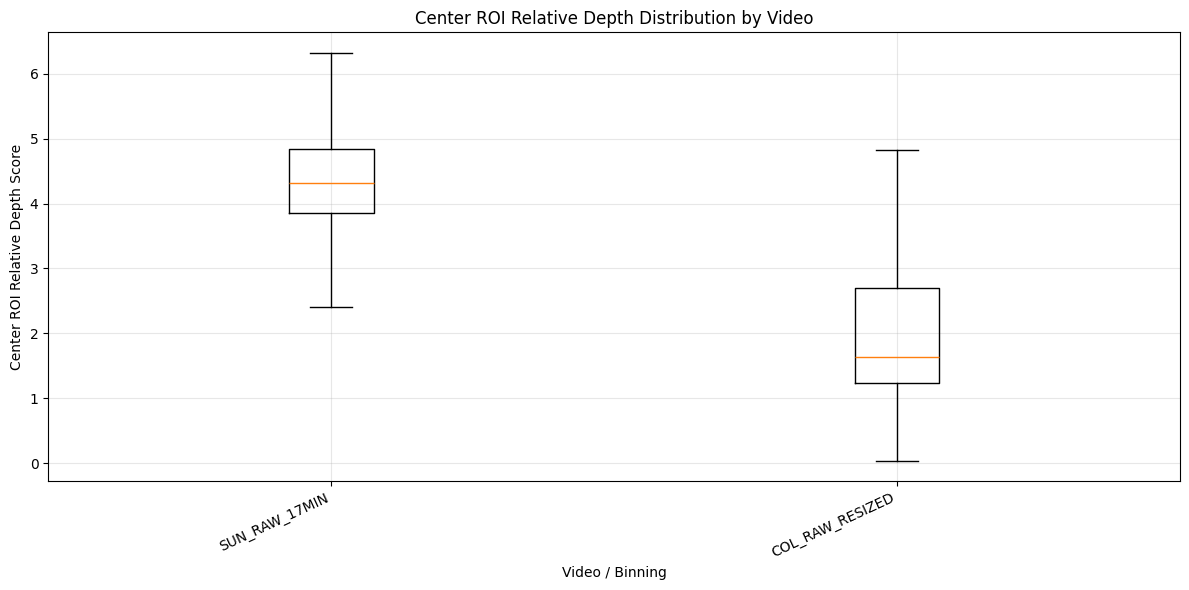

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/combined_center_roi_relative_depth_distribution_boxplot.png


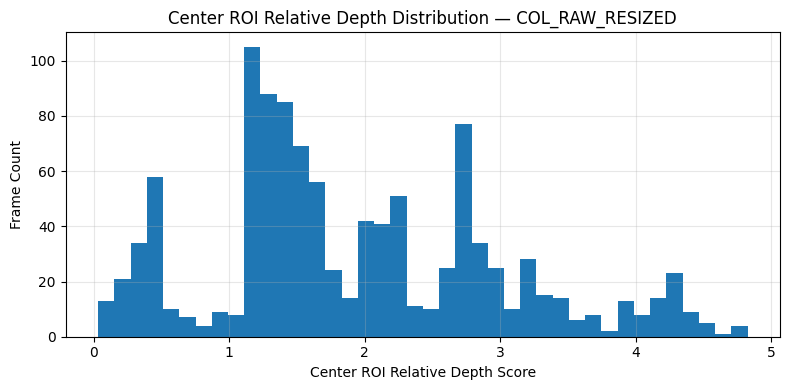

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/COL_RAW_RESIZED_center_roi_relative_depth_histogram.png


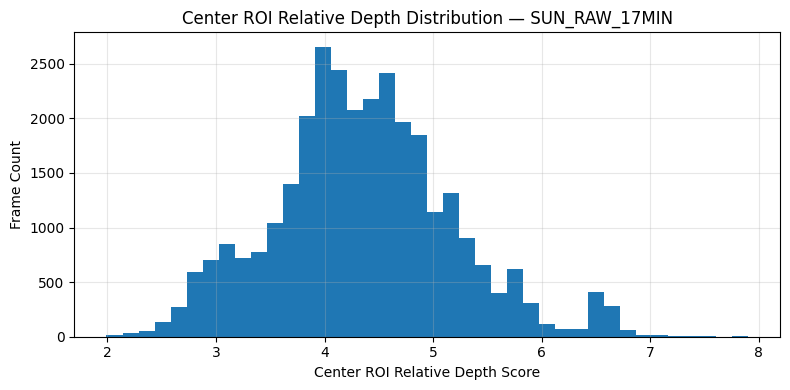

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/SUN_RAW_17MIN_center_roi_relative_depth_histogram.png


In [12]:
# Combined center ROI boxplot
plot_df = combined_metadata_df.copy()
plot_df["plot_label"] = plot_df["source_id"]

boxplot_path = PLOT_DIR / "combined_center_roi_relative_depth_distribution_boxplot.png"

labels = list(plot_df["plot_label"].unique())
data = [plot_df.loc[plot_df["plot_label"] == label, "center_roi_mean"].dropna().values for label in labels]

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Center ROI Relative Depth Distribution by Video")
plt.xlabel("Video / Binning")
plt.ylabel("Center ROI Relative Depth Score")
plt.xticks(rotation=25, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(boxplot_path, dpi=150)
plt.show()

print("Saved:", boxplot_path)

# Per-video histogram plots
for source_id, group in combined_metadata_df.groupby("source_id"):
    hist_path = PER_VIDEO_PLOT_DIR / f"{source_id}_center_roi_relative_depth_histogram.png"

    plt.figure(figsize=(8, 4))
    plt.hist(group["center_roi_mean"].dropna(), bins=40)
    plt.title(f"Center ROI Relative Depth Distribution — {source_id}")
    plt.xlabel("Center ROI Relative Depth Score")
    plt.ylabel("Frame Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(hist_path, dpi=150)
    plt.show()

    print("Saved:", hist_path)

## 14. Reprojection and Depth Consistency Trends Per Binning

Each video receives separate trend plots for:

- minimum reprojection loss
- normalized depth temporal MAE
- normalized depth temporal RMSE

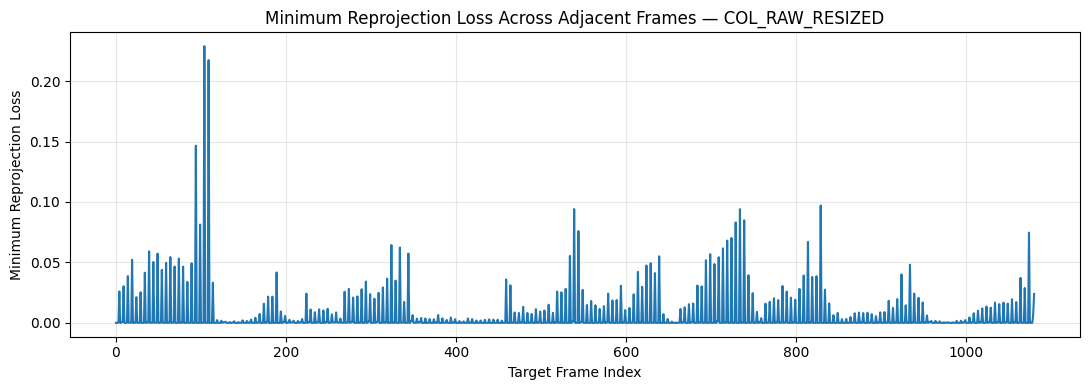

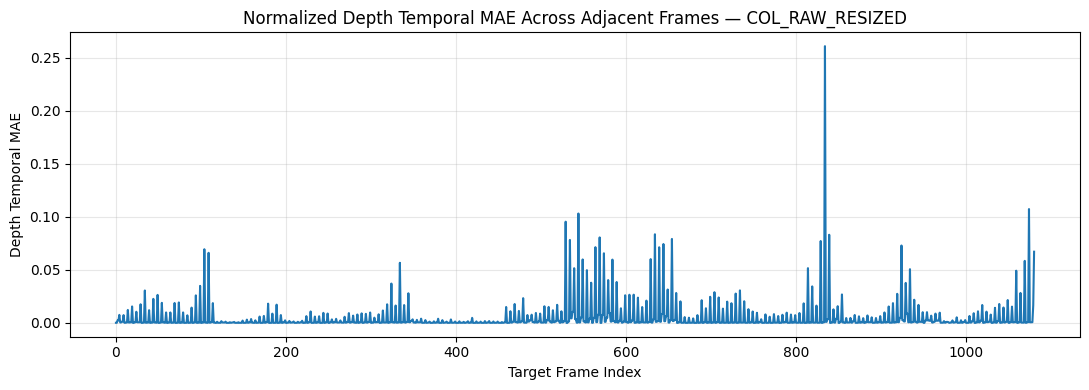

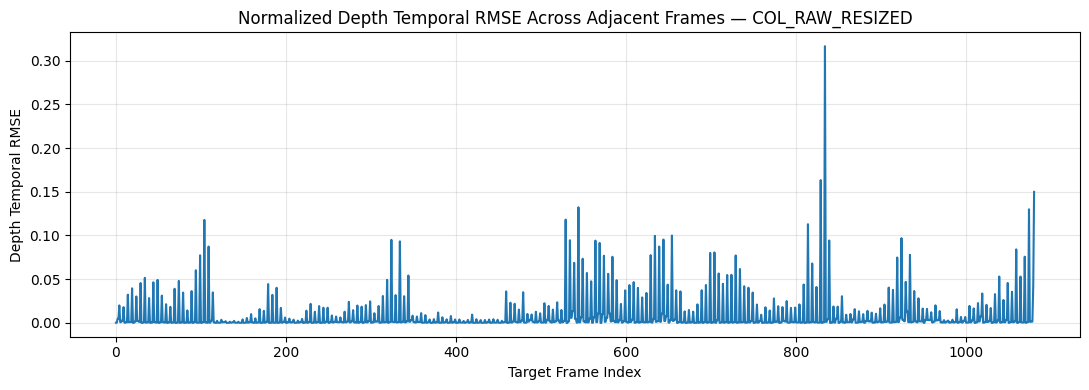

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/COL_RAW_RESIZED_minimum_reprojection_loss_trend.png
Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/COL_RAW_RESIZED_depth_temporal_mae_trend.png
Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/COL_RAW_RESIZED_depth_temporal_rmse_trend.png


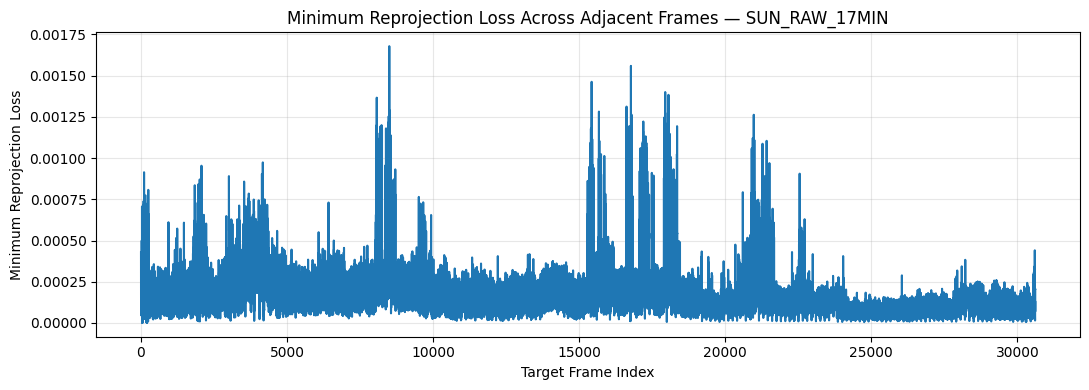

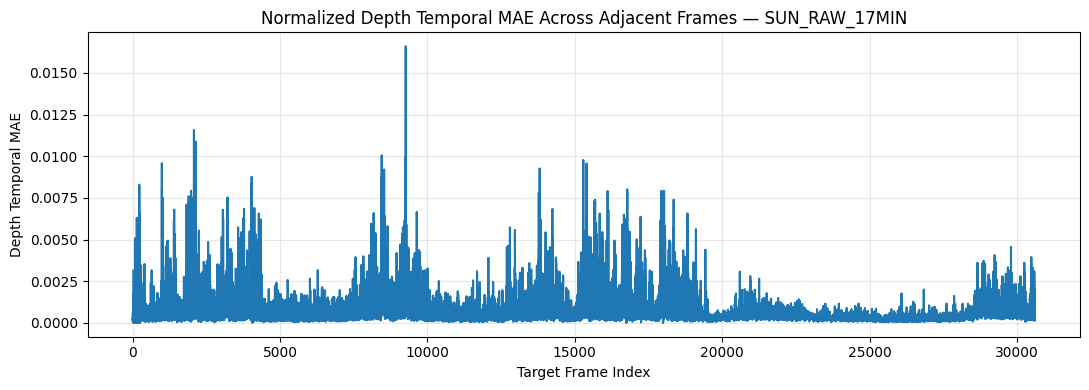

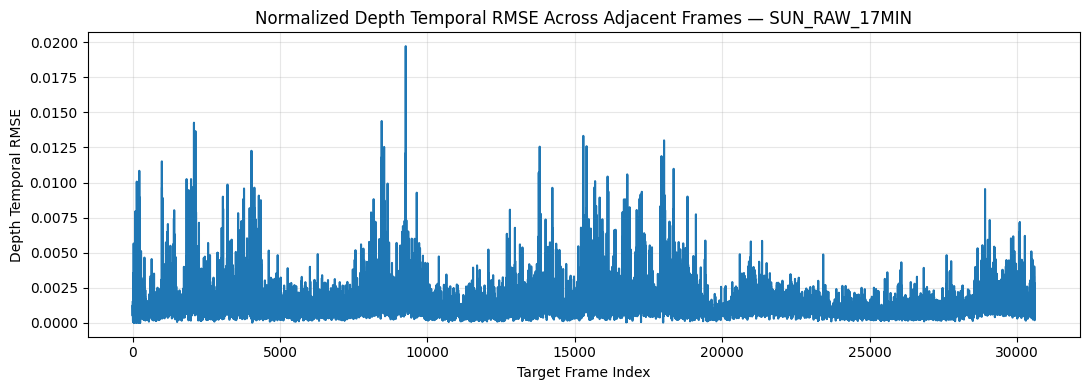

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/SUN_RAW_17MIN_minimum_reprojection_loss_trend.png
Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/SUN_RAW_17MIN_depth_temporal_mae_trend.png
Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video/SUN_RAW_17MIN_depth_temporal_rmse_trend.png


In [13]:
for source_id, group in combined_validation_df.groupby("source_id"):
    group = group.sort_values("target_frame_index").reset_index(drop=True)

    # Minimum reprojection loss trend
    reproj_path = PER_VIDEO_PLOT_DIR / f"{source_id}_minimum_reprojection_loss_trend.png"
    plt.figure(figsize=(11, 4))
    plt.plot(group["target_frame_index"], group["min_reprojection_loss"])
    plt.title(f"Minimum Reprojection Loss Across Adjacent Frames — {source_id}")
    plt.xlabel("Target Frame Index")
    plt.ylabel("Minimum Reprojection Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(reproj_path, dpi=150)
    plt.show()

    # Depth temporal MAE trend
    mae_path = PER_VIDEO_PLOT_DIR / f"{source_id}_depth_temporal_mae_trend.png"
    plt.figure(figsize=(11, 4))
    plt.plot(group["target_frame_index"], group["depth_temporal_mae"])
    plt.title(f"Normalized Depth Temporal MAE Across Adjacent Frames — {source_id}")
    plt.xlabel("Target Frame Index")
    plt.ylabel("Depth Temporal MAE")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(mae_path, dpi=150)
    plt.show()

    # Depth temporal RMSE trend
    rmse_path = PER_VIDEO_PLOT_DIR / f"{source_id}_depth_temporal_rmse_trend.png"
    plt.figure(figsize=(11, 4))
    plt.plot(group["target_frame_index"], group["depth_temporal_rmse"])
    plt.title(f"Normalized Depth Temporal RMSE Across Adjacent Frames — {source_id}")
    plt.xlabel("Target Frame Index")
    plt.ylabel("Depth Temporal RMSE")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(rmse_path, dpi=150)
    plt.show()

    print("Saved:", reproj_path)
    print("Saved:", mae_path)
    print("Saved:", rmse_path)

## 15. Combined Rolling Trend Plots

These combined plots use rolling averages to make the trends easier to compare across bins.

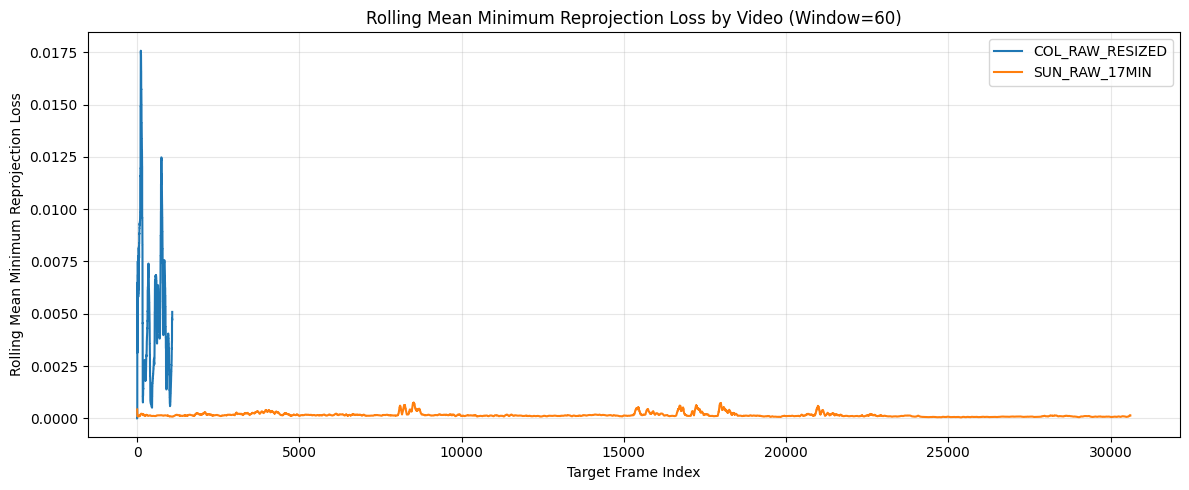

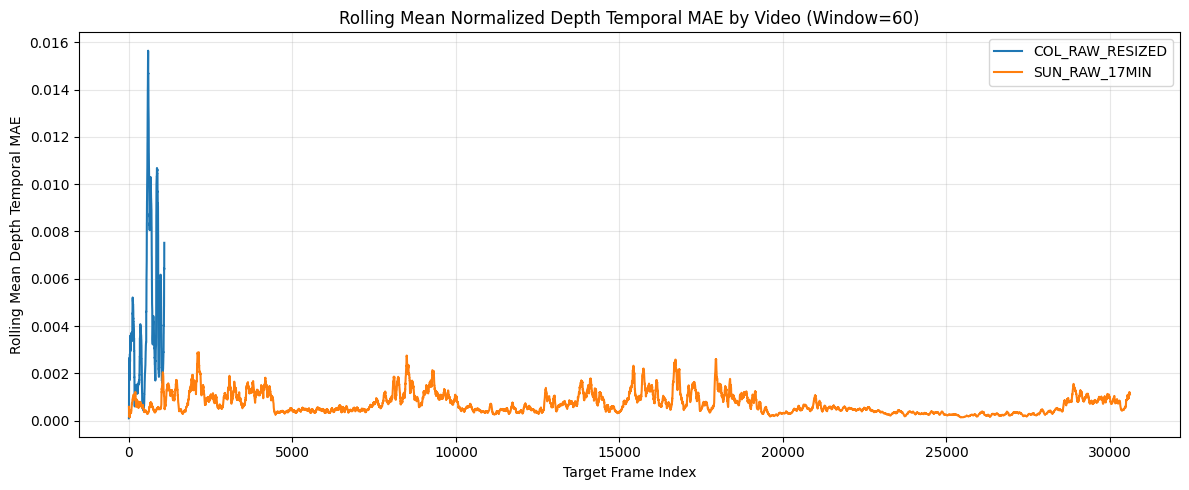

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/combined_rolling_minimum_reprojection_loss_by_video.png
Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/combined_rolling_depth_temporal_mae_by_video.png


In [14]:
ROLLING_WINDOW = 60

rolling_reproj_path = PLOT_DIR / "combined_rolling_minimum_reprojection_loss_by_video.png"
plt.figure(figsize=(12, 5))

for source_id, group in combined_validation_df.groupby("source_id"):
    group = group.sort_values("target_frame_index").reset_index(drop=True)
    rolling = group["min_reprojection_loss"].rolling(ROLLING_WINDOW, min_periods=1).mean()
    plt.plot(group["target_frame_index"], rolling, label=source_id)

plt.title(f"Rolling Mean Minimum Reprojection Loss by Video (Window={ROLLING_WINDOW})")
plt.xlabel("Target Frame Index")
plt.ylabel("Rolling Mean Minimum Reprojection Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(rolling_reproj_path, dpi=150)
plt.show()

rolling_mae_path = PLOT_DIR / "combined_rolling_depth_temporal_mae_by_video.png"
plt.figure(figsize=(12, 5))

for source_id, group in combined_validation_df.groupby("source_id"):
    group = group.sort_values("target_frame_index").reset_index(drop=True)
    rolling = group["depth_temporal_mae"].rolling(ROLLING_WINDOW, min_periods=1).mean()
    plt.plot(group["target_frame_index"], rolling, label=source_id)

plt.title(f"Rolling Mean Normalized Depth Temporal MAE by Video (Window={ROLLING_WINDOW})")
plt.xlabel("Target Frame Index")
plt.ylabel("Rolling Mean Depth Temporal MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(rolling_mae_path, dpi=150)
plt.show()

print("Saved:", rolling_reproj_path)
print("Saved:", rolling_mae_path)

## 16. Minimum Reprojection Loss Distribution

This graph shows how many adjacent-frame pairs fall into low or high reprojection error ranges.

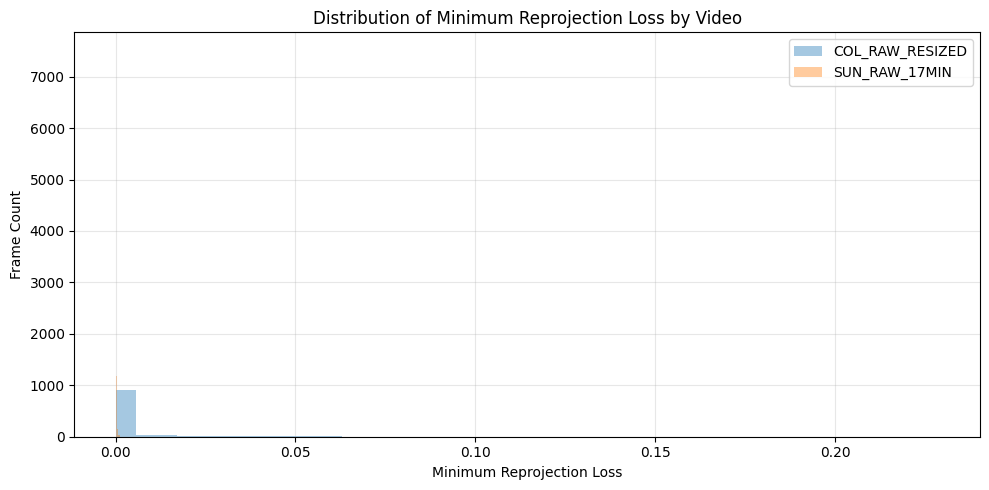

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/combined_minimum_reprojection_loss_distribution.png


In [15]:
combined_hist_path = PLOT_DIR / "combined_minimum_reprojection_loss_distribution.png"

plt.figure(figsize=(10, 5))
for source_id, group in combined_validation_df.groupby("source_id"):
    plt.hist(group["min_reprojection_loss"].dropna(), bins=40, alpha=0.4, label=source_id)

plt.title("Distribution of Minimum Reprojection Loss by Video")
plt.xlabel("Minimum Reprojection Loss")
plt.ylabel("Frame Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(combined_hist_path, dpi=150)
plt.show()

print("Saved:", combined_hist_path)

## 17. Show Saved Sample Validation Pairs

The samples are saved under `sample_validation_pairs`. Each sample includes:

1. Target frame  
2. Warped adjacent source frame  
3. Photometric error map  
4. Target DAV2 depth  
5. Warped source DAV2 depth  
6. Depth difference map

In [16]:
sample_files = sorted(SAMPLE_DIR.glob("*/*.png"))

print("Total sample validation-pair images:", len(sample_files))
for sample_file in sample_files[:10]:
    print(sample_file)
    display(Image(filename=str(sample_file)))

Output hidden; open in https://colab.research.google.com to view.

## 18. Auto-Generated Validation Interpretation Text

This produces a conservative discussion text. It avoids claiming metric-depth accuracy.

In [17]:
discussion_rows = []

for _, row in validation_summary_long.iterrows():
    source_id = row["source_id"]
    loss_mean = row["min_reprojection_loss_mean"]
    loss_median = row["min_reprojection_loss_median"]
    mae_mean = row["depth_temporal_mae_mean"]
    rmse_mean = row["depth_temporal_rmse_mean"]
    valid_mean = row["valid_pixel_ratio_mean"]
    count = int(row["min_reprojection_loss_count"])

    if loss_mean < 0.10:
        consistency_label = "low average reprojection error"
    elif loss_mean < 0.20:
        consistency_label = "moderate average reprojection error"
    else:
        consistency_label = "high average reprojection error"

    text = (
        f"{source_id}: DAV2 validation processed {count:,} adjacent-frame targets. "
        f"The mean minimum reprojection loss was {loss_mean:.4f}, with a median of {loss_median:.4f}. "
        f"The mean normalized depth temporal MAE was {mae_mean:.4f}, while the mean normalized depth temporal RMSE was {rmse_mean:.4f}. "
        f"The mean valid pixel ratio was {valid_mean:.4f}. "
        f"These results indicate {consistency_label} for adjacent-frame relative depth consistency. "
        f"This does not prove exact real-world distance accuracy because no ground-truth depth or calibrated metric reference was used."
    )

    discussion_rows.append({
        "source_id": source_id,
        "discussion_text": text
    })

discussion_df = pd.DataFrame(discussion_rows)
discussion_csv = TABLE_DIR / "dav2_validation_discussion_text_by_video.csv"
discussion_txt = OUTPUT_ROOT / "dav2_validation_discussion_text_by_video.txt"

discussion_df.to_csv(discussion_csv, index=False)

with open(discussion_txt, "w", encoding="utf-8") as f:
    for item in discussion_rows:
        f.write(item["discussion_text"] + "\n\n")

print("Saved:", discussion_csv)
print("Saved:", discussion_txt)

for item in discussion_rows:
    print("\n" + item["discussion_text"])

Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_validation_discussion_text_by_video.csv
Saved: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/dav2_validation_discussion_text_by_video.txt

COL_RAW_RESIZED: DAV2 validation processed 1,081 adjacent-frame targets. The mean minimum reprojection loss was 0.0050, with a median of 0.0001. The mean normalized depth temporal MAE was 0.0045, while the mean normalized depth temporal RMSE was 0.0078. The mean valid pixel ratio was 0.9983. These results indicate low average reprojection error for adjacent-frame relative depth consistency. This does not prove exact real-world distance accuracy because no ground-truth depth or calibrated metric reference was used.

SUN_RAW_17MIN: DAV2 validation processed 30,612 adjacent-frame targets. The mean minimum reprojection loss was 0.0002, with a median of 0.0001. The mean normalized depth temporal MAE was 0.0007, while the mean normali

## 19. Output Checklist

Run this cell at the end to confirm where the generated outputs are stored.

In [18]:
print("DAV2 validation completed.")
print("Output root:", OUTPUT_ROOT)
print("Tables/CSVs:", TABLE_DIR)
print("Excel workbook:", TABLE_DIR / "dav2_validation_tables_workbook.xlsx")
print("Plots:", PLOT_DIR)
print("Per-video plots:", PER_VIDEO_PLOT_DIR)
print("Sample validation pairs:", SAMPLE_DIR)
print("Sample depth outputs:", DEPTH_SAMPLE_DIR)
print("Logs:", LOG_DIR)

print("\nImportant main files:")
for p in [
    TABLE_DIR / "video_inventory.csv",
    TABLE_DIR / "dav2_all_videos_frame_depth_metadata.csv",
    TABLE_DIR / "dav2_all_videos_adjacent_frame_validation.csv",
    TABLE_DIR / "dav2_depth_output_summary_by_video.csv",
    TABLE_DIR / "dav2_center_roi_relative_depth_distribution_table.csv",
    TABLE_DIR / "dav2_validation_summary_by_video.csv",
    TABLE_DIR / "dav2_validation_tables_workbook.xlsx",
    OUTPUT_ROOT / "dav2_validation_discussion_text_by_video.txt",
]:
    print("-", p, "| exists:", p.exists())

DAV2 validation completed.
Output root: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS
Tables/CSVs: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv
Excel workbook: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/dav2_validation_tables_workbook.xlsx
Plots: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots
Per-video plots: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/plots/per_video
Sample validation pairs: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_validation_pairs
Sample depth outputs: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/sample_depth_outputs
Logs: /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/logs

Important main files:
- /content/drive/MyDrive/Thesis2/[DAV2]_SUNSET_PLUS_COLLISION_ONLY_RESULTS/tables_csv/video_inventory.csv | exists: 